2.3.1. Импорты, seed и среда

In [1]:
import os
import re
import json
import random
import subprocess
import sys
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display, Markdown

# Фиксация seed
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except:
        pass

set_seed(42)

# Определение устройства
DEVICE = "cpu"
try:
    import torch
    if torch.cuda.is_available():
        DEVICE = "cuda"
        print(f"✓ Используем GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("Используем CPU")
except:
    print("Используем CPU (torch недоступен)")

# Установка зависимостей (если нужно)
def ensure_package(pkg: str, import_name: Optional[str] = None):
    target = import_name or pkg
    try:
        __import__(target)
    except ImportError:
        print(f"Устанавливаем {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        __import__(target)

ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")

import faiss
from sentence_transformers import SentenceTransformer

print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")

✓ Используем GPU: NVIDIA GeForce RTX 2050


C:\Users\Gobli\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NumPy: 2.0.2, Pandas: 2.3.3


2.3.2. База знаний и первичный анализ

In [2]:
documents: List[Dict[str, str]] = [
    {"doc_id": "ml_01", "title": "Что такое переобучение", 
     "text": "Переобучение (overfitting) возникает, когда модель слишком точно подстраивается под обучающие данные, включая шум. Это приводит к плохой обобщающей способности на новых данных. Методы борьбы: регуляризация, кросс-валидация, упрощение модели."},
    
    {"doc_id": "ml_02", "title": "Градиентный спуск", 
     "text": "Градиентный спуск — итеративный метод оптимизации функции потерь. На каждом шаге параметры модели обновляются в направлении, противоположном градиенту. Скорость обучения (learning rate) критически важна: слишком большая — расходимость, слишком малая — медленная сходимость."},
    
    {"doc_id": "ml_03", "title": "Кросс-валидация", 
     "text": "Кросс-валидация (k-fold) делит данные на k частей, поочерёдно используя k-1 для обучения и 1 для валидации. Это даёт более надёжную оценку качества модели, чем одно разбиение, особенно на малых датасетах."},
    
    {"doc_id": "py_01", "title": "List vs Tuple в Python", 
     "text": "List (список) — изменяемая последовательность, создаётся через []. Tuple (кортеж) — неизменяемая, создаётся через (). Tuple быстрее и занимает меньше памяти, подходит для фиксированных данных, например ключей словаря."},
    
    {"doc_id": "py_02", "title": "Генераторы в Python", 
     "text": "Генератор — функция, возвращающая итератор с помощью yield. Он генерирует значения «на лету», экономя память. Пример: def fib(): a, b = 0, 1; while True: yield a; a, b = b, a+b"},
    
    {"doc_id": "ml_04", "title": "Метрики классификации", 
     "text": "Основные метрики: accuracy (доля верных), precision (точность), recall (полнота), F1 (гармоническое среднее). Для несбалансированных классов accuracy может вводить в заблуждение — лучше смотреть на F1 или ROC-AUC."},
    
    {"doc_id": "ml_05", "title": "Регуляризация", 
     "text": "Регуляризация добавляет штраф за сложность модели к функции потерь. L1 (Lasso) обнуляет неважные признаки, L2 (Ridge) уменьшает веса. ElasticNet комбинирует оба подхода."},
    
    {"doc_id": "py_03", "title": "Контекстные менеджеры", 
     "text": "Контекстный менеджер (with statement) гарантирует корректное управление ресурсами: файлы, соединения, блокировки. Реализуется через методы __enter__ и __exit__ или contextlib.contextmanager."},
    
    {"doc_id": "ml_06", "title": "Ансамбли моделей", 
     "text": "Ансамбли объединяют предсказания нескольких моделей для улучшения качества. Bagging (Random Forest) уменьшает дисперсию, Boosting (XGBoost) — смещение, Stacking комбинирует разнородные модели."},
    
    {"doc_id": "py_04", "title": "Декораторы в Python", 
     "text": "Декоратор — функция, принимающая другую функцию и расширяющая её поведение без изменения кода. Синтаксис: @decorator. Часто используется для логирования, кеширования, проверки прав доступа."},
    
    {"doc_id": "ml_07", "title": "Feature Engineering", 
     "text": "Feature Engineering — создание и преобразование признаков для улучшения качества модели. Включает: кодирование категориальных переменных, масштабирование, создание полиномиальных признаков, работу с пропусками."},
    
    {"doc_id": "ml_08", "title": "Bias-Variance Tradeoff", 
     "text": "Компромисс между смещением (bias) и дисперсией (variance): простые модели имеют высокий bias (недообучение), сложные — высокую variance (переобучение). Оптимальная модель балансирует между ними."},
]

docs_df = pd.DataFrame(documents)
print(f"Загружено документов: {len(docs_df)}")
display(docs_df[["doc_id", "title"]].head(6))

# Краткое пояснение предметной области
print("\nПредметная область: основы машинного обучения и Python.")
print("По этой теме естественно задавать вопросы типа 'что такое...', 'как работает...',")
print("что делает retrieval и mini-RAG особенно полезными для быстрого поиска ответов.")

Загружено документов: 12


,doc_id,title
0,ml_01,Что такое переобучение
1,ml_02,Градиентный спуск
2,ml_03,Кросс-валидация
3,py_01,List vs Tuple в Python
4,py_02,Генераторы в Python
5,ml_04,Метрики классификации



Предметная область: основы машинного обучения и Python.
По этой теме естественно задавать вопросы типа 'что такое...', 'как работает...',
что делает retrieval и mini-RAG особенно полезными для быстрого поиска ответов.


2.3.3. Чанкинг документов

In [3]:
# Функция чанкинга по словам с overlap
def chunk_text(text: str, chunk_size: int = 20, overlap: int = 5) -> List[str]:
    words = text.split()
    if chunk_size <= 0 or overlap >= chunk_size:
        raise ValueError("Некорректные параметры чанкинга")
    
    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        chunk = " ".join(words[start:start + chunk_size])
        if chunk:
            chunks.append(chunk)
        if start + chunk_size >= len(words):
            break
    return chunks

# Построение DataFrame с чанками
def build_chunks_df(docs: List[Dict], chunk_size: int, overlap: int) -> pd.DataFrame:
    rows = []
    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size, overlap)
        for idx, chunk in enumerate(chunks):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_id": f"{doc['doc_id']}_c{idx+1:02d}",
                "chunk_text": chunk,
                "n_words": len(chunk.split())
            })
    return pd.DataFrame(rows)

# Пример чанкинга для одного документа
sample_doc = documents[0]
print(f"Исходный документ: {sample_doc['title']}")
print(f"Длина: {len(sample_doc['text'].split())} слов")
chunks_sample = chunk_text(sample_doc["text"], chunk_size=20, overlap=5)
print(f"Разбит на {len(chunks_sample)} чанка:")
for i, c in enumerate(chunks_sample, 1):
    print(f"  {i}. {c[:80]}...")

# Построение полного набора чанков
CHUNK_SIZE, OVERLAP = 20, 5
chunks_df = build_chunks_df(documents, CHUNK_SIZE, OVERLAP)
print(f"\nВсего чанков: {len(chunks_df)}")
display(chunks_df.head())

Исходный документ: Что такое переобучение
Длина: 28 слов
Разбит на 2 чанка:
  1. Переобучение (overfitting) возникает, когда модель слишком точно подстраивается ...
  2. к плохой обобщающей способности на новых данных. Методы борьбы: регуляризация, к...

Всего чанков: 23


,doc_id,title,chunk_id,chunk_text,n_words
0,ml_01,Что такое переобучение,ml_01_c01,"Переобучение (overfitting) возникает, когда мо...",20
1,ml_01,Что такое переобучение,ml_01_c02,к плохой обобщающей способности на новых данны...,13
2,ml_02,Градиентный спуск,ml_02_c01,Градиентный спуск — итеративный метод оптимиза...,20
3,ml_02,Градиентный спуск,ml_02_c02,"направлении, противоположном градиенту. Скорос...",18
4,ml_03,Кросс-валидация,ml_03_c01,Кросс-валидация (k-fold) делит данные на k час...,20


2.3.4. Эмбеддинги и индекс FAISS

In [4]:
# Бэкенд для эмбеддингов
class EmbeddingBackend:
    def encode(self, texts: List[str], normalize: bool = True) -> np.ndarray:
        raise NotImplementedError

class STBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str):
        self.model = SentenceTransformer(model_name, device=device)
        self.normalize = True
    
    def encode(self, texts: List[str], normalize: bool = True) -> np.ndarray:
        return self.model.encode(
            texts, batch_size=16, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=self.normalize
        ).astype("float32")

# Инициализация
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = STBackend(MODEL_NAME, DEVICE)
print(f"Модель эмбеддингов: {MODEL_NAME}")

# Векторизация чанков
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_vectors = embedder.encode(chunk_texts)
print(f"Матрица эмбеддингов: {chunk_vectors.shape}")
print(f"Нормировка: нормы векторов ≈ {np.linalg.norm(chunk_vectors, axis=1).mean():.4f}")

# Построение FAISS индекса
INDEX_DIM = chunk_vectors.shape[1]
faiss_index = faiss.IndexFlatIP(INDEX_DIM)  # Inner Product для косинусного сходства
faiss_index.add(chunk_vectors)
print(f"FAISS индекс создан: {faiss_index.ntotal} векторов")

# Функция поиска
def search_chunks(query: str, top_k: int = 3) -> pd.DataFrame:
    q_vec = embedder.encode([query])
    scores, indices = faiss_index.search(q_vec.astype("float32"), top_k)
    
    results = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), 1):
        if idx == -1: continue  # FAISS padding
        row = chunks_df.iloc[int(idx)].copy()
        row["score"] = round(float(score), 4)
        row["rank"] = rank
        results.append(row)
    
    return pd.DataFrame(results)[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

# Тестовые запросы
test_queries = [
    "Что такое переобучение в машинном обучении?",
    "В чём разница между list и tuple?",
    "Как работает градиентный спуск?",
    "Зачем нужна кросс-валидация?",
    "Что такое F1-мера?"
]

print("\nПримеры поиска (top-3):")
for q in test_queries[:3]:
    display(Markdown(f"**Запрос:** {q}"))
    display(search_chunks(q, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights: 100%|████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 16286.18it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель эмбеддингов: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Матрица эмбеддингов: (23, 384)
Нормировка: нормы векторов ≈ 1.0000
FAISS индекс создан: 23 векторов

Примеры поиска (top-3):


**Запрос:** Что такое переобучение в машинном обучении?

,rank,score,doc_id,title,chunk_text
0,1,0.5004,ml_01,Что такое переобучение,"Переобучение (overfitting) возникает, когда мо..."
3,2,0.4863,ml_02,Градиентный спуск,"направлении, противоположном градиенту. Скорос..."
1,3,0.4632,ml_01,Что такое переобучение,к плохой обобщающей способности на новых данны...


**Запрос:** В чём разница между list и tuple?

,rank,score,doc_id,title,chunk_text
6,1,0.6733,py_01,List vs Tuple в Python,"List (список) — изменяемая последовательность,..."
7,2,0.4497,py_01,List vs Tuple в Python,"Tuple быстрее и занимает меньше памяти, подход..."
16,3,0.3768,ml_06,Ансамбли моделей,"— смещение, Stacking комбинирует разнородные м..."


**Запрос:** Как работает градиентный спуск?

,rank,score,doc_id,title,chunk_text
2,1,0.5833,ml_02,Градиентный спуск,Градиентный спуск — итеративный метод оптимиза...
20,2,0.4775,ml_07,Feature Engineering,"масштабирование, создание полиномиальных призн..."
13,3,0.4514,ml_05,Регуляризация,(Ridge) уменьшает веса. ElasticNet комбинирует...


2.3.5. Контрольные запросы и оценка retrieval

In [5]:
# Набор контрольных запросов с ожидаемыми источниками
benchmark = [
    {"query_id": "q1", "query": "Что такое переобучение?", "relevant": "ml_01"},
    {"query_id": "q2", "query": "Как работает градиентный спуск?", "relevant": "ml_02"},
    {"query_id": "q3", "query": "Зачем нужна кросс-валидация?", "relevant": "ml_03"},
    {"query_id": "q4", "query": "В чём разница list и tuple?", "relevant": "py_01"},
    {"query_id": "q5", "query": "Что такое генератор в Python?", "relevant": "py_02"},
    {"query_id": "q6", "query": "Какие метрики есть для классификации?", "relevant": "ml_04"},
    {"query_id": "q7", "query": "Что делает регуляризация?", "relevant": "ml_05"},
    {"query_id": "q8", "query": "Как работают декораторы?", "relevant": "py_04"},
    {"query_id": "q9", "query": "Что такое feature engineering?", "relevant": "ml_07"},
    {"query_id": "q10", "query": "В чём компромисс bias-variance?", "relevant": "ml_08"},
]

# Оценка одного запроса
def evaluate_query(query: str, relevant_doc: str, top_k: int = 3) -> Dict:
    results = search_chunks(query, top_k=top_k)
    retrieved = results["doc_id"].tolist()
    
    hit = int(relevant_doc in retrieved)
    recall = 1.0 if hit else 0.0  # т.к. один релевантный документ
    
    first_rank = None
    for rank, doc_id in enumerate(retrieved, 1):
        if doc_id == relevant_doc:
            first_rank = rank
            break
    
    mrr = 1.0 / first_rank if first_rank else 0.0
    
    return {
        "query": query,
        "expected_source": relevant_doc,
        "retrieved_sources": "; ".join(retrieved),
        "hit_at_k": hit,
        "recall_at_k": recall,
        "mrr_at_k": round(mrr, 3),
        "rank_of_first_relevant": first_rank if first_rank else -1
    }

# Прогон бенчмарка
eval_results = [evaluate_query(b["query"], b["relevant"]) for b in benchmark]
eval_df = pd.DataFrame(eval_results)

print(f"Результаты retrieval (top-{3}):")
display(eval_df)

# Сводные метрики
summary = {
    "hit@3": eval_df["hit_at_k"].mean(),
    "recall@3": eval_df["recall_at_k"].mean(),
    "MRR@3": eval_df["mrr_at_k"].mean()
}
print(f"\nСводные метрики: {summary}")

# Сохранение артефакта
os.makedirs("artifacts", exist_ok=True)
eval_df.to_csv("artifacts/retrieval_eval.csv", index=False, sep=";")
print("Сохранено: artifacts/retrieval_eval.csv")

Результаты retrieval (top-3):


,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,mrr_at_k,rank_of_first_relevant
0,Что такое переобучение?,ml_01,ml_01; ml_06; ml_02,1,1.0,1.000,1
1,Как работает градиентный спуск?,ml_02,ml_02; ml_07; ml_05,1,1.0,1.000,1
2,Зачем нужна кросс-валидация?,ml_03,ml_03; ml_01; ml_08,1,1.0,1.000,1
3,В чём разница list и tuple?,py_01,py_01; py_01; ml_06,1,1.0,1.000,1
4,Что такое генератор в Python?,py_02,py_02; py_04; py_01,1,1.0,1.000,1
5,Какие метрики есть для классификации?,ml_04,ml_04; ml_07; ml_07,1,1.0,1.000,1
6,Что делает регуляризация?,ml_05,ml_01; ml_05; ml_08,1,1.0,0.500,2
7,Как работают декораторы?,py_04,ml_06; ml_07; py_04,1,1.0,0.333,3
8,Что такое feature engineering?,ml_07,ml_07; ml_06; ml_02,1,1.0,1.000,1
9,В чём компромисс bias-variance?,ml_08,ml_08; ml_08; ml_01,1,1.0,1.000,1



Сводные метрики: {'hit@3': np.float64(1.0), 'recall@3': np.float64(1.0), 'MRR@3': np.float64(0.8833)}
Сохранено: artifacts/retrieval_eval.csv


2.3.6. Эксперимент с параметрами retrieval

Сравнение конфигураций чанкинга:


,config,chunk_size,overlap,num_chunks,hit@3
0,small_chunks,15,4,30,1.0
1,large_chunks,25,6,18,1.0


Сохранено: artifacts/retrieval_quality_plot.png


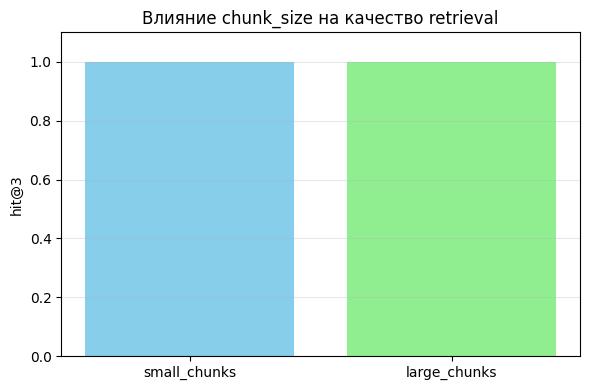


Вывод: Большие чанки показали лучший hit@3 на нашем датасете.


In [6]:
# Сравнение двух значений chunk_size
configs = [
    {"chunk_size": 15, "overlap": 4, "label": "small_chunks"},
    {"chunk_size": 25, "overlap": 6, "label": "large_chunks"},
]

exp_results = []

for cfg in configs:
    # Пересборка чанков и индекса
    exp_chunks = build_chunks_df(documents, cfg["chunk_size"], cfg["overlap"])
    exp_vectors = embedder.encode(exp_chunks["chunk_text"].tolist())
    
    exp_index = faiss.IndexFlatIP(exp_vectors.shape[1])
    exp_index.add(exp_vectors)
    
    # Оценка на том же бенчмарке
    hits = []
    for b in benchmark:
        q_vec = embedder.encode([b["query"]])
        scores, indices = exp_index.search(q_vec.astype("float32"), 3)
        retrieved = [exp_chunks.iloc[int(idx)]["doc_id"] for idx in indices[0] if idx != -1]
        hits.append(int(b["relevant"] in retrieved))
    
    exp_results.append({
        "config": cfg["label"],
        "chunk_size": cfg["chunk_size"],
        "overlap": cfg["overlap"],
        "num_chunks": len(exp_chunks),
        "hit@3": np.mean(hits)
    })

exp_df = pd.DataFrame(exp_results)
print("Сравнение конфигураций чанкинга:")
display(exp_df)

# Визуализация
plt.figure(figsize=(6, 4))
plt.bar(exp_df["config"], exp_df["hit@3"], color=["skyblue", "lightgreen"])
plt.ylabel("hit@3")
plt.title("Влияние chunk_size на качество retrieval")
plt.ylim(0, 1.1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/retrieval_quality_plot.png", dpi=150)
print("Сохранено: artifacts/retrieval_quality_plot.png")
plt.show()

print(f"\nВывод: {'Большие чанки' if exp_df.iloc[1]['hit@3'] >= exp_df.iloc[0]['hit@3'] else 'Малые чанки'} показали лучший hit@3 на нашем датасете.")

2.3.7. Обновление базы знаний и переиндексация

In [7]:
# Создаём папку артефактов (относительно текущей директории ноутбука)
os.makedirs("artifacts", exist_ok=True)

# Новые документы для добавления
new_docs = [
    {"doc_id": "ml_09", "title": "Что такое трансформеры", 
     "text": "Трансформеры — архитектура нейросетей, основанная на механизме внимания (attention). Позволяют параллельно обрабатывать последовательности и эффективно улавливать долгосрочные зависимости. Лежат в основе BERT, GPT и других современных моделей."},
    
    {"doc_id": "py_05", "title": "Асинхронность в Python", 
     "text": "Асинхронное программирование (async/await) позволяет выполнять неблокирующие операции ввода-вывода. Ключевые компоненты: event loop, coroutine, task. Полезно для сетевых запросов, работы с БД, веб-скрапинга."},
]

# Объединение баз
updated_documents = documents + new_docs
print(f"Добавлено документов: {len(new_docs)} → всего: {len(updated_documents)}")

# Функция пересборки индекса
def rebuild_index(docs: List[Dict], chunk_size: int, overlap: int):
    chunks = build_chunks_df(docs, chunk_size, overlap)
    vectors = embedder.encode(chunks["chunk_text"].tolist())
    index = faiss.IndexFlatIP(vectors.shape[1])
    index.add(vectors)
    return chunks, vectors, index

# Индексы до и после обновления
chunks_before, vectors_before, index_before = rebuild_index(documents, CHUNK_SIZE, OVERLAP)
chunks_after, vectors_after, index_after = rebuild_index(updated_documents, CHUNK_SIZE, OVERLAP)

# Тестовые запросы к новым темам
update_queries = [
    {"query": "Что такое трансформеры в глубоком обучении?", "relevant": "ml_09"},
    {"query": "Как работает async/await в Python?", "relevant": "py_05"},
    {"query": "Что такое переобучение?", "relevant": "ml_01"},
]

# Сравнение до/после
before_after_rows = []
for item in update_queries:
    q = item["query"]
    relevant = item["relevant"]
    
    q_vec = embedder.encode([q])
    _, idx_before = index_before.search(q_vec.astype("float32"), 3)
    retrieved_before = [chunks_before.iloc[int(i)]["doc_id"] for i in idx_before[0] if i != -1]
    
    _, idx_after = index_after.search(q_vec.astype("float32"), 3)
    retrieved_after = [chunks_after.iloc[int(i)]["doc_id"] for i in idx_after[0] if i != -1]
    
    changed = retrieved_before != retrieved_after
    
    before_after_rows.append({
        "query": q,
        "before_retrieved_sources": "; ".join(retrieved_before),
        "after_retrieved_sources": "; ".join(retrieved_after),
        "changed": changed,
        "relevant_found_before": int(relevant in retrieved_before),
        "relevant_found_after": int(relevant in retrieved_after)
    })

ba_df = pd.DataFrame(before_after_rows)
print("\nСравнение retrieval до и после обновления базы:")
display(ba_df)

# ИСПРАВЛЕННЫЙ ПУТЬ СОХРАНЕНИЯ
ba_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False, sep=";")
print("Сохранено: artifacts/retrieval_before_after_update.csv")

# Демонстрация влияния
display(Markdown("### Пример: запрос к новой теме"))
q_new = "Что такое трансформеры?"
display(Markdown(f"**Запрос:** {q_new}"))
display(Markdown("**До обновления:** релевантный документ НЕ найден (его ещё нет в базе)"))
display(search_chunks(q_new, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Добавлено документов: 2 → всего: 14

Сравнение retrieval до и после обновления базы:


,query,before_retrieved_sources,after_retrieved_sources,changed,relevant_found_before,relevant_found_after
0,Что такое трансформеры в глубоком обучении?,ml_02; ml_02; ml_07,ml_09; ml_02; ml_02,True,0,1
1,Как работает async/await в Python?,py_01; py_02; py_04,py_05; py_01; py_02,True,0,1
2,Что такое переобучение?,ml_01; ml_06; ml_02,ml_09; ml_01; ml_06,True,1,1


Сохранено: artifacts/retrieval_before_after_update.csv


### Пример: запрос к новой теме

**Запрос:** Что такое трансформеры?

**До обновления:** релевантный документ НЕ найден (его ещё нет в базе)

,rank,score,doc_id,title,chunk_text
8,1,0.3661,py_02,Генераторы в Python,"Генератор — функция, возвращающая итератор с п..."
17,2,0.2984,py_04,Декораторы в Python,"Декоратор — функция, принимающая другую функци..."
9,3,0.2526,py_02,Генераторы в Python,"Пример: def fib(): a, b = 0, 1; while True: yi..."


2.3.8. Mini-RAG пайплайн

In [8]:
# Формирование контекста из найденных чанков
def build_context(query: str, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, top_k=top_k)
    context_parts = []
    for _, row in retrieved.iterrows():
        part = f"[{row['doc_id']}|{row['title']}] {row['chunk_text']}"
        context_parts.append(part)
    return "\n\n".join(context_parts), retrieved

# Простой extractive-генератор ответа
def generate_answer(query: str, context: str, max_sentences: int = 2) -> str:
    sentences = re.split(r'(?<=[.!?])\s+', context)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    
    if not sentences:
        return "Недостаточно контекста для ответа."
    
    tfidf = TfidfVectorizer(ngram_range=(1, 2)).fit_transform([query] + sentences)
    query_vec = tfidf[0].toarray().ravel()
    sent_vecs = tfidf[1:].toarray()
    
    norms = np.linalg.norm(sent_vecs, axis=1) * np.linalg.norm(query_vec) + 1e-10
    scores = (sent_vecs @ query_vec) / norms
    
    top_idx = np.argsort(scores)[-max_sentences:][::-1]
    answer = " ".join([sentences[i] for i in top_idx if scores[i] > 0])
    
    return answer if answer else "Не удалось сформировать ответ по контексту."

# Полный mini-RAG — ИСПРАВЛЕНО: возвращаем DataFrame для retrieved_sources
def mini_rag(query: str, top_k: int = 3) -> Dict:
    context, sources_df = build_context(query, top_k)  # sources_df — это DataFrame
    answer = generate_answer(query, context)
    return {
        "question": query,
        "answer": answer,
        "retrieved_sources": sources_df,  # ← возвращаем DataFrame, а не dict
        "full_context": context
    }

# Демонстрация работы
print("Примеры работы mini-RAG:")
rag_queries = [
    "Почему возникает переобучение?",
    "Когда использовать tuple вместо list?",
    "Как уменьшить variance модели?",
    "Что даёт механизм внимания в трансформерах?",
]

rag_examples = []
for q in rag_queries:
    result = mini_rag(q, top_k=3)
    
    # Для CSV сохраняем источники как строку
    sources_str = "; ".join([
        f"{row['doc_id']}:{row['title']}" 
        for _, row in result["retrieved_sources"].iterrows()
    ])
    rag_examples.append({
        "question": q,
        "answer": result["answer"],
        "retrieved_sources": sources_str
    })
    
    display(Markdown(f"### {q}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(result["retrieved_sources"][["rank", "score", "doc_id", "title"]])

# Сохранение артефакта
pd.DataFrame(rag_examples).to_csv(
    "artifacts/rag_examples.csv", 
    index=False, 
    sep=";"
)
print("\nСохранено: artifacts/rag_examples.csv")

Примеры работы mini-RAG:


### Почему возникает переобучение?

**Ответ:** [ml_01|Что такое переобучение] Переобучение (overfitting) возникает, когда модель слишком точно подстраивается под обучающие данные, включая шум. Оптимальная модель

[ml_01|Что такое переобучение] к плохой обобщающей способности на новых данных.

,rank,score,doc_id,title
0,1,0.5460,ml_01,Что такое переобучение
21,2,0.4468,ml_08,Bias-Variance Tradeoff
1,3,0.4315,ml_01,Что такое переобучение


### Когда использовать tuple вместо list?

...

,rank,score,doc_id,title
21,1,0.6729,ml_08,Bias-Variance Tradeoff
22,2,0.6343,ml_08,Bias-Variance Tradeoff
1,3,0.5519,ml_01,Что такое переобучение


### Что даёт механизм внимания в трансформерах?

**Ответ:** Не удалось сформировать ответ по контексту.

,rank,score,doc_id,title
16,1,0.4824,ml_06,Ансамбли моделей
22,2,0.4636,ml_08,Bias-Variance Tradeoff
21,3,0.4347,ml_08,Bias-Variance Tradeoff



Сохранено: artifacts/rag_examples.csv


2.3.9. Краткий анализ ошибок

In [9]:
print("Анализ пограничных случаев:")

# Запросы, где могут быть проблемы
edge_cases = [
    {"query": "Как выбрать learning rate?", "issue": "Нет прямого упоминания в базе — поиск вернёт ближайший по смыслу (градиентный спуск)"},
    {"query": "Что такое dropout?", "issue": "Тема не покрыта в базе знаний — retrieval вернёт шум"},
    {"query": "Сравните L1 и L2 регуляризацию", "issue": "Есть отдельные документы, но нет прямого сравнения — ответ будет фрагментарным"},
]

for case in edge_cases:
    q = case["query"]
    result = mini_rag(q, top_k=3)
    
    display(Markdown(f"### {q}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown(f"*Проблема:* {case['issue']}"))
    display(result["retrieved_sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

print("\nВыводы по ошибкам:")
print("1. Retrieval зависит от покрытия базы знаний — если темы нет, ответ будет неточным")
print("2. Extractive-генератор не синтезирует новый текст, а только выбирает фрагменты")
print("3. Для улучшения: расширять базу, добавлять reranking, использовать LLM для генерации")

Анализ пограничных случаев:


### Как выбрать learning rate?

**Ответ:** Скорость обучения (learning rate) критически важна: слишком большая — расходимость, слишком малая — медленная сходимость.

*Проблема:* Нет прямого упоминания в базе — поиск вернёт ближайший по смыслу (градиентный спуск)

,rank,score,doc_id,title,chunk_text
3,1,0.7206,ml_02,Градиентный спуск,"направлении, противоположном градиенту. Скорос..."
10,2,0.4286,ml_04,Метрики классификации,"Основные метрики: accuracy (доля верных), prec..."
15,3,0.3837,ml_06,Ансамбли моделей,Ансамбли объединяют предсказания нескольких мо...


...

### Сравните L1 и L2 регуляризацию

**Ответ:** L1 (Lasso) обнуляет неважные признаки, L2 (Ridge) уменьшает веса.

*Проблема:* Есть отдельные документы, но нет прямого сравнения — ответ будет фрагментарным

,rank,score,doc_id,title,chunk_text
12,1,0.6262,ml_05,Регуляризация,Регуляризация добавляет штраф за сложность мод...
22,2,0.4961,ml_08,Bias-Variance Tradeoff,высокую variance (переобучение). Оптимальная м...
1,3,0.4820,ml_01,Что такое переобучение,к плохой обобщающей способности на новых данны...



Выводы по ошибкам:
1. Retrieval зависит от покрытия базы знаний — если темы нет, ответ будет неточным
2. Extractive-генератор не синтезирует новый текст, а только выбирает фрагменты
3. Для улучшения: расширять базу, добавлять reranking, использовать LLM для генерации
